In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Create the project's data folder if it does not exist
os.makedirs('data', exist_ok=True)

In [2]:
from utils import get_stock_data

df = get_stock_data('sz.000001', '2024-01-01', '2024-12-31', adjustflag='2')
print(f"Shape: {df.shape}")
df.head()

login success!
logout success!
Shape: (242, 7)


,code,open,high,low,close,volume,amount
date,,,,,,,
2024-01-02,sz.000001,8.143365,8.169382,7.987262,7.987262,115836645,1.075742e+09
2024-01-03,sz.000001,7.969917,7.995934,7.935228,7.978590,73361031,6.736736e+08
2024-01-04,sz.000001,7.969917,7.969917,7.874521,7.900538,86419399,7.874701e+08
2024-01-05,sz.000001,7.891866,8.186727,7.865849,8.039296,199162216,1.852660e+09
2024-01-08,sz.000001,8.004607,8.065313,7.900538,7.935228,112115619,1.029007e+09


In [3]:
df['simple_return'] = df['close'].pct_change()
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['difference'] = df['simple_return'] - df['log_return']

df.head()

,code,open,high,low,close,volume,amount,simple_return,log_return,difference
date,,,,,,,,,,
2024-01-02,sz.000001,8.143365,8.169382,7.987262,7.987262,115836645,1.075742e+09,NaN,NaN,NaN
2024-01-03,sz.000001,7.969917,7.995934,7.935228,7.978590,73361031,6.736736e+08,-0.001086,-0.001086,5.898821e-07
2024-01-04,sz.000001,7.969917,7.969917,7.874521,7.900538,86419399,7.874701e+08,-0.009783,-0.009831,4.816409e-05
2024-01-05,sz.000001,7.891866,8.186727,7.865849,8.039296,199162216,1.852660e+09,0.017563,0.017411,1.524491e-04
2024-01-08,sz.000001,8.004607,8.065313,7.900538,7.935228,112115619,1.029007e+09,-0.012945,-0.013030,8.451647e-05


In [4]:
df.to_csv('data/sz000001_with_returns.csv')
print("Saved to data/sz000001_with_returns.csv")

Saved to data/sz000001_with_returns.csv


In [5]:
df[['close', 'simple_return', 'log_return']].describe()

,close,simple_return,log_return
count,242.000000,241.000000,241.000000
mean,9.648678,0.001504,0.001369
std,0.967627,0.016473,0.016359
min,7.883193,-0.093168,-0.097798
25%,9.117307,-0.007231,-0.007258
50%,9.412634,0.000000,0.000000
75%,10.679580,0.008780,0.008741
max,11.967890,0.099796,0.095125


In [6]:
print("Mean:", df['simple_return'].mean())
print("Median:", df['simple_return'].median())
print(df.max)
print(df.min)


Mean: 0.0015038167954208967
Median: 0.0
<bound method DataFrame.max of                  code       open       high        low      close     volume  \
date                                                                           
2024-01-02  sz.000001   8.143365   8.169382   7.987262   7.987262  115836645   
2024-01-03  sz.000001   7.969917   7.995934   7.935228   7.978590   73361031   
2024-01-04  sz.000001   7.969917   7.969917   7.874521   7.900538   86419399   
2024-01-05  sz.000001   7.891866   8.186727   7.865849   8.039296  199162216   
2024-01-08  sz.000001   8.004607   8.065313   7.900538   7.935228  112115619   
...               ...        ...        ...        ...        ...        ...   
2024-12-25  sz.000001  11.261153  11.413074  11.242163  11.318123  147528294   
2024-12-26  sz.000001  11.318123  11.327619  11.185192  11.261153  100007470   
2024-12-27  sz.000001  11.270648  11.299133  11.071252  11.232668  129001228   
2024-12-30  sz.000001  11.185192  11.365599  11.1

In [7]:
cumulative_return = (1 + df['simple_return']).prod() - 1
print(f"Cumulative 2024 return: {cumulative_return:.2%}")

Cumulative 2024 return: 39.09%


In [8]:
# Pull unadjusted data
df_raw = get_stock_data('sz.000001', '2024-01-01', '2024-12-31', adjustflag='3')

# Compare the starting and ending prices
print("Adjusted (前复权) data:")
print(f"  First close: {df['close'].iloc[0]:.2f}")
print(f"  Last close:  {df['close'].iloc[-1]:.2f}")
print(f"  Price-only return: {(df['close'].iloc[-1]/df['close'].iloc[0] - 1):.2%}")

print("\nUnadjusted (不复权) data:")
print(f"  First close: {df_raw['close'].iloc[0]:.2f}")
print(f"  Last close:  {df_raw['close'].iloc[-1]:.2f}")
print(f"  Price-only return: {(df_raw['close'].iloc[-1]/df_raw['close'].iloc[0] - 1):.2%}")

login success!
logout success!
Adjusted (前复权) data:
  First close: 7.99
  Last close:  11.11
  Price-only return: 39.09%

Unadjusted (不复权) data:
  First close: 9.21
  Last close:  11.70
  Price-only return: 27.04%


In [9]:
print(f"Skewness: {df['simple_return'].skew():.4f}")
print(f"Kurtosis: {df['simple_return'].kurtosis():.4f}")

Skewness: 0.8582
Kurtosis: 10.6726


In [10]:
# Identify the 5 largest absolute-return days
largest_moves = df['simple_return'].abs().nlargest(5)
print("5 largest absolute moves:")
print(df.loc[largest_moves.index, ['simple_return', 'close']].sort_index())

5 largest absolute moves:
            simple_return      close
date                                
2024-02-21       0.099796   9.366170
2024-09-26       0.061905  10.360402
2024-09-30       0.069177  11.345337
2024-10-08       0.054873  11.967890
2024-10-09      -0.093168  10.852869


In [11]:
# Compute statistics with and without the top 5 extreme days
top5_indices = largest_moves.index
df_trimmed = df.drop(top5_indices)

print("Full 2024 data:")
print(f"  Mean: {df['simple_return'].mean():.4f}")
print(f"  Std:  {df['simple_return'].std():.4f}")
print(f"  Skew: {df['simple_return'].skew():.4f}")
print(f"  Kurt: {df['simple_return'].kurtosis():.4f}")

print("\nWith 5 most extreme days removed:")
print(f"  Mean: {df_trimmed['simple_return'].mean():.4f}")
print(f"  Std:  {df_trimmed['simple_return'].std():.4f}")
print(f"  Skew: {df_trimmed['simple_return'].skew():.4f}")
print(f"  Kurt: {df_trimmed['simple_return'].kurtosis():.4f}")

Full 2024 data:
  Mean: 0.0015
  Std:  0.0165
  Skew: 0.8582
  Kurt: 10.6726

With 5 most extreme days removed:
  Mean: 0.0007
  Std:  0.0123
  Skew: 0.4962
  Kurt: 0.9838


In [12]:
import pandas as pd

stocks = {
    # 大盘股
    'sz.000001': '平安银行',
    'sh.600519': '贵州茅台',
    'sh.601318': '中国平安',
    # 小盘股
    'sz.000705': '浙江震元',
    'sh.600156': '华升股份',
    'sz.300960': '通业科技',
}

# Label each stock as large or small cap for later grouping
caps = {
    'sz.000001': '大盘',
    'sh.600519': '大盘',
    'sh.601318': '大盘',
    'sz.000705': '小盘',
    'sh.600156': '小盘',
    'sz.300960': '小盘',
}

start = '2024-01-01'
end = '2025-01-01'

# Collect statistics into a list of dicts
results = []
for code, name in stocks.items():
    df_stock = get_stock_data(code, start, end)
    returns = df_stock['close'].pct_change().dropna()
    
    results.append({
        'code': code,
        'name': name,
        'cap': caps[code],
        'mean': returns.mean(),
        'std': returns.std(),
        'skew': returns.skew(),
        'kurt': returns.kurtosis(),
        'n_days': len(returns),
    })

# Build the comparison table
comparison = pd.DataFrame(results)
comparison = comparison.set_index('name')
comparison

login success!
logout success!
login success!
logout success!
login success!
logout success!
login success!
logout success!
login success!
logout success!
login success!
logout success!


,code,cap,mean,std,skew,kurt,n_days
name,,,,,,,
平安银行,sz.000001,大盘,0.001504,0.016473,0.858196,10.672633,241
贵州茅台,sh.600519,大盘,-0.000120,0.017353,1.429349,8.340199,241
中国平安,sh.601318,大盘,0.001584,0.018680,0.696805,7.638444,241
浙江震元,sz.000705,小盘,-0.000922,0.027316,-0.067693,1.882247,241
华升股份,sh.600156,小盘,0.000699,0.041939,0.088906,0.613654,241
通业科技,sz.300960,小盘,0.002165,0.055517,0.638794,4.202041,241


In [13]:
group_summary = comparison.groupby('cap')[['mean', 'std', 'skew', 'kurt']].mean()
group_summary

,mean,std,skew,kurt
cap,,,,
大盘,0.000989,0.017502,0.994783,8.883759
小盘,0.000647,0.041590,0.220002,2.232647


login success!
logout success!
Chinese font set to: Microsoft YaHei


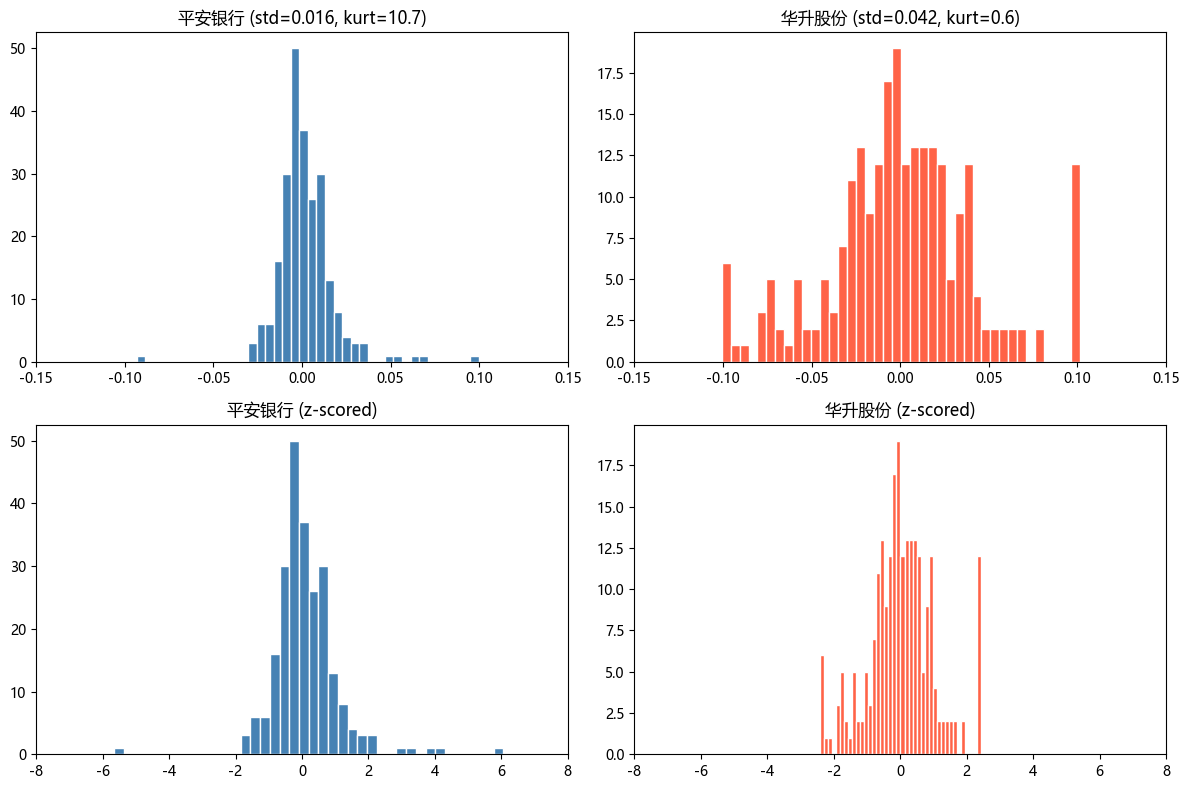

In [14]:
# Pull 华升股份 data separately and compute returns
df_huasheng = get_stock_data('sh.600156', '2024-01-01', '2025-01-01')
df_huasheng['simple_return'] = df_huasheng['close'].pct_change()

# Alias df to df_pingan for clarity in the plot code
df_pingan = df

# Set up Chinese font for plotting
from plot_setup import setup_chinese_font
setup_chinese_font()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top row: same x-axis scale for both, makes scale difference visible
axes[0, 0].hist(df_pingan['simple_return'].dropna(), bins=40, 
                color='steelblue', edgecolor='white')
axes[0, 0].set_title('平安银行 (std=0.016, kurt=10.7)')
axes[0, 0].set_xlim(-0.15, 0.15)

axes[0, 1].hist(df_huasheng['simple_return'].dropna(), bins=40, 
                color='tomato', edgecolor='white')
axes[0, 1].set_title('华升股份 (std=0.042, kurt=0.6)')
axes[0, 1].set_xlim(-0.15, 0.15)

# Bottom row: normalized by each stock's own std (z-scores), 
# makes shape difference visible
pingan_z = df_pingan['simple_return'].dropna() / df_pingan['simple_return'].std()
huasheng_z = df_huasheng['simple_return'].dropna() / df_huasheng['simple_return'].std()

axes[1, 0].hist(pingan_z, bins=40, color='steelblue', edgecolor='white')
axes[1, 0].set_title('平安银行 (z-scored)')
axes[1, 0].set_xlim(-8, 8)

axes[1, 1].hist(huasheng_z, bins=40, color='tomato', edgecolor='white')
axes[1, 1].set_title('华升股份 (z-scored)')
axes[1, 1].set_xlim(-8, 8)

plt.tight_layout()
plt.show()